# IVS Weekmonitor Analysis & UN/LOCODE Mapping

This notebook demonstrates how to process the IVS weekmonitor data from Rijkswaterstaat, aggregate cargo by origin-destination (OD) pairs, and map these flows to the inland waterway network using ISRS locodes and Zenodo reference data.

In [1]:
import pathlib
import zipfile
import io
import requests
import pickle
import itertools
import logging
from collections import defaultdict

import pandas as pd
import geopandas as gpd
import shapely.wkt
import shapely.geometry
import networkx as nx
import matplotlib.pyplot as plt
import contextily as cx
import numpy as np
from tqdm.auto import tqdm

# Set up logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

/Users/baart_f/src/fis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load IVS Data Directly from Internet
We fetch the latest weekmonitor ZIP and read the CSV content in-memory.

In [2]:
ivs_url = "https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip"

logger.info(f"Fetching IVS data from {ivs_url}...")
r = requests.get(ivs_url, timeout=30)
r.raise_for_status()

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        ivs_df = pd.read_csv(f, sep=";")

logger.info(f"Loaded {len(ivs_df)} records from {csv_filename}.")
ivs_df.head()

INFO: Fetching IVS data from https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip...


INFO: Loaded 55646 records from IVS_weekmonitor_31MAR2026.csv.


,Jaarmaand,Jaar,Maand,Weeknr,v05_06_Begindt_evenement_iso,v05_06_Begindt_evenement,UNLO_herkomst,UNLO_bestemming,v15_1_Scheepstype_RWS,SK_CODE,v18_Laadvermogen,v28_Beladingscode,v38_Vervoerd_gewicht,v30_4_Containers_TEU_S,nstr_nw,nst2007_nw
0,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,DEFRA,2,M8,2660,7,1303000.0,0,3.0,7.2
1,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,NLAMS,2,M8,3550,7,1030000.0,0,3.0,8.5
2,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLLEY,NLUTC,1,M8,3230,7,514125.0,65,9.0,19.2
3,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLAMS,FRSXB,2,M9,3500,7,2122000.0,0,3.0,7.2
4,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEGNE,BEANR,2,M10,5220,7,2704000.0,0,8.0,8.2


## 2. Load Network and Analyze Locations
We load the merged graph and analyze the distribution of `sectionjunction` nodes for major locations.

INFO: Loaded network with 7089 nodes.


INFO: Found 323 sectionjunction nodes for NLRTM (Rotterdam)


Sample of rtm_3857 nodes:


,name,locode,geometry
FIS_8867170,Vaarwegvakjunctie ViN(3030),NLRTM01040J303000002,POINT (501682.109 6784843.14)
FIS_8868442,Vaarwegvakjunctie ViN(3031),NLRTM01040J303100007,POINT (501818.262 6784019.129)
FIS_8862214,Vaarwegvakjunctie ViN(412),NLRTM00116J041200121,POINT (459335.952 6793830.418)
FIS_8866780,Vaarwegvakjunctie ViN(3313),NLRTM00116J331300126,POINT (458582.408 6794175.143)
FIS_8863982,Vaarwegvakjunctie ViN(112),NLRTM0102IJ011200010,POINT (486063.472 6780293.613)


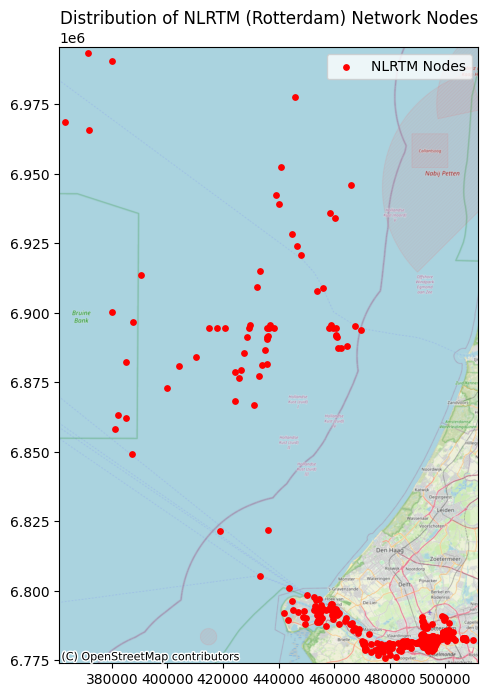

In [3]:
graph_path = pathlib.Path("../output/merged-graph/graph.pickle")
with graph_path.open("rb") as f:
    graph = pickle.load(f)

# Create nodes GDF from graph nodes
nodes_gdf = gpd.GeoDataFrame(
    graph.nodes.values(), index=graph.nodes.keys(), crs="EPSG:4326"
)
logger.info(f"Loaded network with {len(nodes_gdf)} nodes.")

# Analyze Rotterdam nodes (NLRTM)
rtm_nodes = nodes_gdf[
    nodes_gdf["locode"].str.contains("NLRTM", na=False)
    & (nodes_gdf["geo_type"] == "sectionjunction")
].copy()
logger.info(f"Found {len(rtm_nodes)} sectionjunction nodes for NLRTM (Rotterdam)")

if not rtm_nodes.empty:
    rtm_3857 = rtm_nodes.to_crs(epsg=3857)
    print("Sample of rtm_3857 nodes:")
    display(rtm_3857[["name", "locode", "geometry"]].head())

    fig, ax = plt.subplots(figsize=(12, 8))
    rtm_3857.plot(ax=ax, color="red", markersize=15, label="NLRTM Nodes")

    bounds = rtm_3857.total_bounds
    if not np.any(np.isnan(bounds)):
        ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
        ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
    ax.set_title("Distribution of NLRTM (Rotterdam) Network Nodes")
    plt.legend(loc="upper right")
    plt.show()

## 3. Aggregate OD Data
We group the cargo data by origin (`UNLO_herkomst`) and destination (`UNLO_bestemming`).

In [4]:
# Filter for Dutch origins and destinations (prefix NL)
nl_mask = ivs_df["UNLO_herkomst"].str.startswith("NL", na=False) & ivs_df[
    "UNLO_bestemming"
].str.startswith("NL", na=False)
ivs_nl = ivs_df[nl_mask].copy()

od_pairs = (
    ivs_nl.groupby(["UNLO_herkomst", "UNLO_bestemming"])["v38_Vervoerd_gewicht"]
    .sum()
    .reset_index()
)
od_pairs = od_pairs.sort_values(by="v38_Vervoerd_gewicht", ascending=False)
top_100_od = od_pairs.head(100)

## 4. Compute Routes and Aggregate Cargo per Fairway Section
We calculate the shortest path for each of the top 100 OD pairs and sum the cargo weight per network edge, avoiding sea routes.

In [5]:
def length_avoid_sea(u, v, d):
    """Custom weight function to penalize sea routes using water_name."""
    length = d.get("length_m", 1.0)
    name = (
        str(d.get("name", "")).lower()
        + str(d.get("ww_name", "")).lower()
        + str(d.get("water_name", "")).lower()
    )
    if "zee" in name or "sea" in name:
        return length * 1000000
    return length


def get_sample_node_for_locode(locode):
    mask = nodes_gdf["locode"].str.contains(locode, na=False)
    junction_mask = nodes_gdf["geo_type"] == "sectionjunction"
    matches = nodes_gdf[mask & junction_mask]
    if matches.empty:
        return None
    return matches.index[0]


edge_cargo = defaultdict(float)
edge_info = {}

for idx, row in tqdm(
    top_100_od.iterrows(), total=len(top_100_od), desc="Routing top 100"
):
    u_loc, v_loc, weight = (
        row["UNLO_herkomst"],
        row["UNLO_bestemming"],
        row["v38_Vervoerd_gewicht"],
    )
    u_node, v_node = (
        get_sample_node_for_locode(u_loc),
        get_sample_node_for_locode(v_loc),
    )

    if u_node and v_node:
        try:
            route = nx.shortest_path(graph, u_node, v_node, weight=length_avoid_sea)
            for u, v in itertools.pairwise(route):
                edge_key = tuple(sorted((u, v)))
                edge_cargo[edge_key] += weight
                if edge_key not in edge_info:
                    edge_info[edge_key] = graph.edges[u, v]
        except nx.NetworkXNoPath:
            continue

collapsed_data = []
for edge_key, weight in edge_cargo.items():
    data = edge_info[edge_key]
    geom_data = data.get("geometry")
    if isinstance(geom_data, str):
        geom = shapely.wkt.loads(geom_data)
    else:
        geom = geom_data

    if geom:
        collapsed_data.append({"geometry": geom, "cargo_weight": weight})

all_routes_gdf = gpd.GeoDataFrame(collapsed_data, crs="EPSG:4326")

Routing top 100:   0%|                                                                               | 0/100 [00:00<?, ?it/s]

Routing top 100:  34%|███████████████████████▍                                             | 34/100 [00:00<00:00, 338.89it/s]

Routing top 100:  70%|████████████████████████████████████████████████▎                    | 70/100 [00:00<00:00, 350.26it/s]

Routing top 100: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 343.34it/s]

## 5. Visualize Cargo Intensity
Display the total cargo volume per fairway section on a background map.

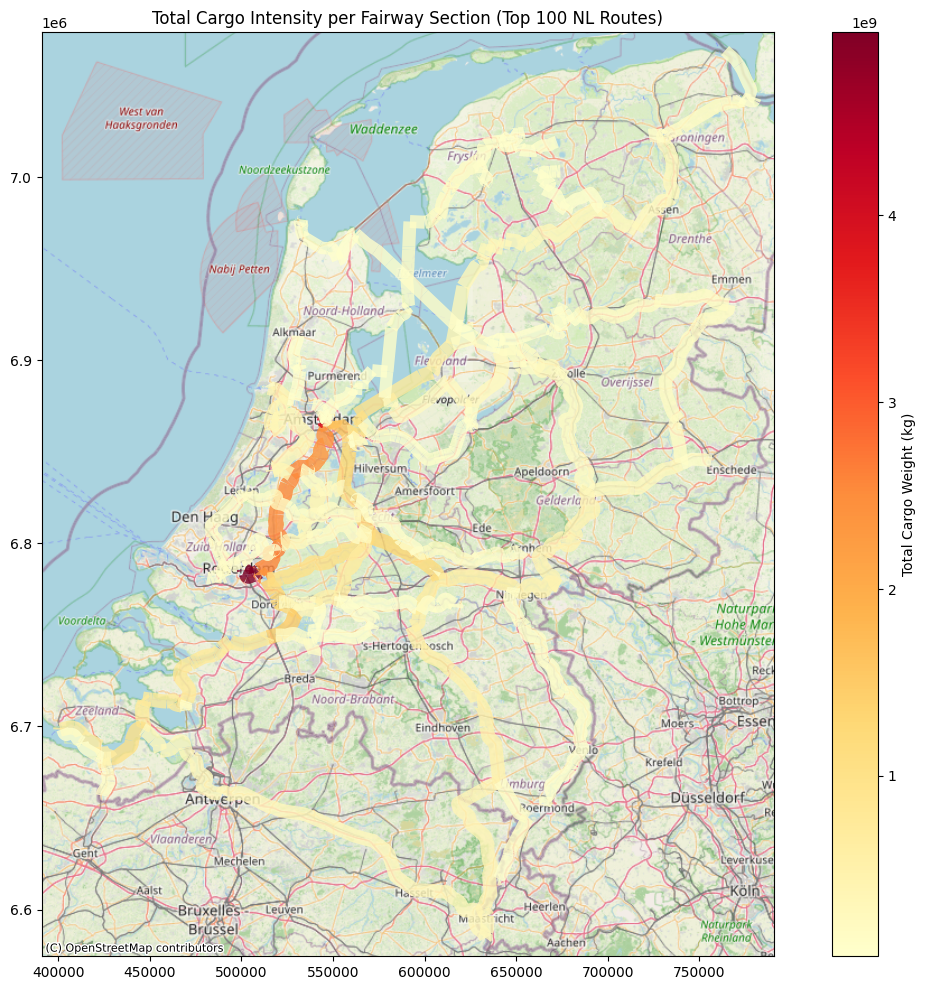

In [6]:
routes_3857 = all_routes_gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(15, 12))

max_weight = routes_3857["cargo_weight"].max()
routes_3857["linewidth"] = 1 + 10 * (
    np.log1p(routes_3857["cargo_weight"]) / np.log1p(max_weight)
)

routes_3857.plot(
    ax=ax,
    column="cargo_weight",
    cmap="YlOrRd",
    linewidth=routes_3857["linewidth"],
    alpha=0.8,
    legend=True,
    legend_kwds={"label": "Total Cargo Weight (kg)"},
)

minx, miny, maxx, maxy = routes_3857.total_bounds
if not np.any(np.isnan([minx, miny, maxx, maxy])):
    ax.set_xlim(minx - 10000, maxx + 10000)
    ax.set_ylim(miny - 10000, maxy + 10000)
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title("Total Cargo Intensity per Fairway Section (Top 100 NL Routes)")
plt.show()